# Project Introduction: Binary Logistic Regression Analysis

### 1. Overview
This project focuses on the implementation and  mathematical evaluation of **Binary Logistic Regression**, a cornerstone algorithm in  Supervised Machine Learning.

While Linear Regression is designed to predict continuous outcomes, Logistic Regression is engineered for **Classification**—predicting the probability that a given input belongs to one of two discrete classes (e.g., Yes/No, Fraud/Legitimate, Healthy/Sick).

### 2. Why Linear Regression Fails for Classification
Using standard linear regression to output raw scores $z = \theta^T x$ for binary classification creates two major structural issues:
1. **Unbounded Limits**: Raw scores can span from $-\infty$ to $+\infty$, whereas classification requires valid probabilities strictly bounded between $0$ and $1$.
2. **Sensitivity to Outliers**: Extreme data points far to one side will pull and tilt a straight linear line, shifting the decision boundary even if the classes are cleanly separated.

### 3. Core Problem Statement
In this analysis, we address the limitations of linear models when applied to categorical data. We aim to construct a predictive engine that:
*   Maps multi-dimensional input features into a bounded probability space $[0, 1]$.
*   Derives an optimal **Decision Boundary** to separate data clusters.
*   Minimizes a non-linear cost function (**Binary Cross-Entropy**) using an iterative **Gradient Descent** optimization strategy.

### 4. Technical Objectives
To achieve a deep, "from-scratch" understanding of the algorithm, this project is divided into the following modular phases:

*   **Mathematical Modeling**: Defining the **Sigmoid (Logistic) Activation Function** and the parametric hypothesis vector $\theta$.

*   **Vectorized Implementation**: Leveraging **Linear Algebra (Matrix Notation)** to ensure the model scales efficiently across large datasets without the use of high-level loops.

*   **Optimization**: Deriving and implementing the gradient calculus required to update model weights based on the error between predicted probabilities and ground-truth labels.

*   **Performance Validation**: Utilizing a robust suite of diagnostic tools, including the **Confusion Matrix**, **ROC/AUC Curves**, and **Sigmoid Projection Plots** to verify model convergence and separation quality.

### 5. Key Terminology
*   **Hypothesis ($H$)**: The predicted probability output by the sigmoid function.
*   **Logit ($Z$)**: The raw linear combination of weights and features ($X\theta$).
*   **Cost Function ($J$)**: The measure of "penalty" for incorrect predictions, optimized via Maximum Likelihood Estimation.
*   **Threshold ($\tau$)**: The decision cutoff (typically $0.5$) used to convert probabilities into final class assignments.



---
## The Matrix Setup
Let $m$ be the total number of training sample rows, and $n$ be the number of physical measured features. We stack our data horizontally into an array and prepend an artificial column containing only the scalar value $1$ at index $0$ to handle the intercept bias $\theta_0$. 

We arrange our ground-truth class labels into a strict column vector $Y$, and our parameters into a weight vector $\theta$:

$$\underset{[m \times (n+1)]}{X} = \begin{bmatrix} 1 & x_1^{(1)} & x_2^{(1)} & \dots & x_n^{(1)} \\ 1 & x_1^{(2)} & x_2^{(2)} & \dots & x_n^{(2)} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_1^{(m)} & x_2^{(m)} & \dots & x_n^{(m)} \end{bmatrix}, \quad \underset{[m \times 1]}{Y} = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(m)} \end{bmatrix}, \quad \underset{[(n+1) \times 1]}{\theta} = \begin{bmatrix} \theta_0 \\ \theta_1 \\ \theta_2 \\ \vdots \\ \theta_n \end{bmatrix}$$

### 3. The Vectorized Hypothesis Layer
To map unbounded linear combinations $Z = X\theta$ into clean probability ranges, we feed them element-wise through the non-linear **Sigmoid Function** $g(z) = \frac{1}{1 + e^{-z}}$. This establishes our **Hypothesis Vector** ($H$), which represents the model's conditional probability estimates that $y=1$ for each sample:

$$\underset{[m \times 1]}{H} = g(X\theta) = \frac{1}{1 + \exp(-X\theta)} = \begin{bmatrix} h_\theta(x^{(1)}) \\ h_\theta(x^{(2)}) \\ \vdots \\ h_\theta(x^{(m)}) \end{bmatrix} = \begin{bmatrix} P(y^{(1)}=1 \mid x^{(1)}; \theta) \\ P(y^{(2)}=1 \mid x^{(2)}; \theta) \\ \vdots \\ P(y^{(m)}=1 \mid x^{(m)}; \theta) \end{bmatrix}$$

$$\text{Complementary Probability Profile: } P(y^{(i)}=0 \mid x^{(i)}; \theta) = 1 - h_\theta(x^{(i)})$$


In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Dimension of Traing set: (800, 2) | Test set: (200, 2)


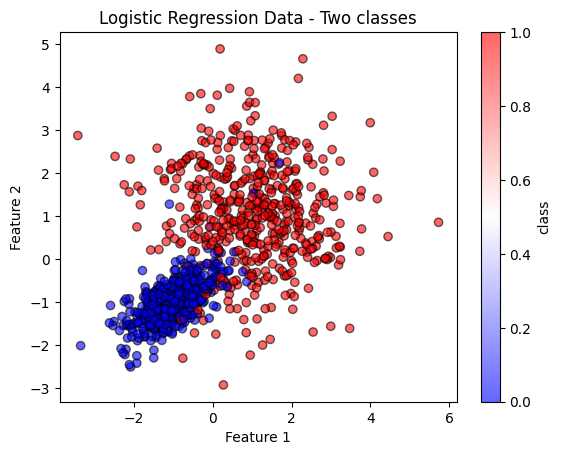

In [55]:
# =======================================
# MODULE 1: DATA FETCHING & VISULISATION   
# =======================================

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X ,y = make_classification(n_samples=1000, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1,
                           random_state=65)

# Splitting the data into traing and test matrix
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=55)

print(f"Dimension of Traing set: {X_train.shape} | Test set: {X_test.shape}")

# Plotting the features 
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k',alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Data - Two classes')
plt.colorbar(label='class')
plt.show()   


# Log-Likelihood & Matrix Cost Function Derivation

### 1. Unifying the Probability Density
We combine our two separate conditional probability equations ($P(y=1)$ and $P(y=0)$) into a single unified mathematical statement using an algebraic exponent trick:

$$p(y^{(i)} \mid x^{(i)}; \theta) = \left( h_\theta(x^{(i)}) \right)^{y^{(i)}} \left( 1 - h_\theta(x^{(i)}) \right)^{1-y^{(i)}}$$

* Verification: If $y^{(i)} = 1$, the right exponent becomes $0$, leaving $h_\theta(x^{(i)})$. If $y^{(i)} = 0$, the left exponent becomes $0$, leaving $1 - h_\theta(x^{(i)})$.

### 2. Maximum Likelihood Estimation (MLE)
Assuming independent and identically distributed (i.i.d.) samples, the joint probability of observing our entire true label vector is the product of their individual probability densities, defined as the **Likelihood Function** $L(\theta)$:

$$L(\theta) = \prod_{i=1}^{m} p(y^{(i)} \mid x^{(i)}; \theta) = \prod_{i=1}^{m} \left( h_\theta(x^{(i)}) \right)^{y^{(i)}} \left( 1 - h_\theta(x^{(i)}) \right)^{1-y^{(i)}}$$

To prevent numerical underflow on computers, we apply the natural logarithm ($\ln$) to turn products into additions, creating the **Log-Likelihood Function** $\ell(\theta)$:

$$\ell(\theta) = \ln L(\theta) = \sum_{i=1}^{m} \left[ y^{(i)} \ln\left(h_\theta(x^{(i)})\right) + (1-y^{(i)}) \ln\left(1 - h_\theta(x^{(i)})\right) \right]$$

### 3. Reconstruction into Matrix Format
To frame this as a cost minimization problem, we multiply the expression by $-1$ and scale it by our dataset size $m$, yielding the **Binary Cross-Entropy Cost Function** $J(\theta)$. We split the summation into two independent vector dot products:

* **Part A (Sum over $y=1$):** $y^{(1)}\ln(h^{(1)}) + \dots + y^{(m)}\ln(h^{(m)}) = Y^T \ln(H)$
* **Part B (Sum over $y=0$):** $(1-y^{(1)})\ln(1-h^{(1)}) + \dots + (1-y^{(m)})\ln(1-h^{(m)}) = (1 - Y)^T \ln(1 - H)$

$$\text{Matrix Cross-Entropy Formula: } J(\theta) = -\frac{1}{m} \left( Y^T \ln(H) + (1 - Y)^T \ln(1 - H) \right)$$

---

# Matrix Calculus Derivation of the Gradient

Because the non-linear sigmoid maps variables inside logarithms, we cannot calculate a closed-form normal equation. We must derive the gradient matrix $\nabla_\theta J(\theta)$ to find our updates. We apply the **Multivariate Vector Chain Rule**:

$$\frac{\partial J(\theta)}{\partial \theta} = \left( \frac{\partial H}{\partial \theta} \right)^T \frac{\partial J(\theta)}{\partial H}$$

### Step A: Differentiate Cost with respect to Hypothesis Vector $\left(\frac{\partial J(\theta)}{\partial H}\right)$
We differentiate the scalar loss $J(\theta)$ with respect to the vertical probability vector $H$:

$$\frac{\partial J(\theta)}{\partial H} = -\frac{1}{m} \left( \frac{Y}{H} - \frac{1 - Y}{1 - H} \right) = -\frac{1}{m} \left( \frac{Y \odot (1 - H) - H \odot (1 - Y)}{H \odot (1 - H)} \right) = \frac{1}{m} \left( \frac{H - Y}{H \odot (1 - H)} \right)$$

*(Note: $\odot$ denotes element-wise vector multiplication).*

### Step B: Differentiate Sigmoid Layer with respect to Parameters $\left(\frac{\partial H}{\partial \theta}\right)$
The calculus derivative of a sigmoid function evaluates to $g'(z) = g(z)(1 - g(z))$. Applying this element-wise across our linear combinations transforms the vector derivative into a square diagonal matrix:

$$\frac{\partial H}{\partial z} = \text{diag}\Big( H \odot (1 - H) \Big)$$

Using the linear matrix derivative rule $\frac{\partial(X\theta)}{\partial \theta} = X$, we complete this leg of the chain:

$$\frac{\partial H}{\partial \theta} = \frac{\partial H}{\partial z} \cdot \frac{\partial z}{\partial \theta} = \text{diag}\Big( H \odot (1 - H) \Big) \cdot X$$

### Step C: Collapse the Matrix Chain Rule Elements
We substitute Step A and Step B back into our master chain rule equation:

$$\frac{\partial J(\theta)}{\partial \theta} = \left( \text{diag}\Big( H \odot (1 - H) \Big) X \right)^T \cdot \left[ \frac{1}{m} \left( \frac{H - Y}{H \odot (1 - H)} \right) \right]$$

Apply the transpose matrix rule $(AB)^T = B^T A^T$. Since a diagonal matrix is perfectly symmetric ($\text{diag}^T = \text{diag}$):

$$\frac{\partial J(\theta)}{\partial \theta} = \frac{1}{m} X^T \cdot \text{diag}\Big( H \odot (1 - H) \Big) \cdot \left( \frac{H - Y}{H \odot (1 - H)} \right)$$

Multiplying any vector by a diagonal matrix is mathematically identical to performing an element-wise multiplication ($\odot$) between those two vectors. The complex denominator components cancel out perfectly:

$$\frac{\partial J(\theta)}{\partial \theta} = \frac{1}{m} X^T \left[ \big( H \odot (1 - H) \big) \odot \left( \frac{H - Y}{H \odot (1 - H)} \right) \right] \implies \frac{\partial J(\theta)}{\partial \theta} = \frac{1}{m} X^T (H - Y)$$

### Step D: Vectorized Gradient Descent Update Rule
We subtract the scaled gradient vector from our current coefficients to iteratively minimize our cost function:

$$\theta := \theta - \alpha \cdot \left[ \frac{1}{m} X^T (H - Y) \right]$$


In [57]:
# =====================================
# MODULE 2: LOGISTIC GRADIENT DESCENT 
# =====================================


# Defining the Activation Fucntion 
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# Cross-Entropy Function
def logistic_loss(y_true, y_pred):
    
    # To avoid log(0) and log(1)
    eps = 1e-15
    logi_loss = -np.mean(y_true * np.log(y_pred + eps )+(1 - y_true)*np.log(1 - y_pred + eps))
    
    return logi_loss

# Gradient calculation
def logistic_gradient(X, y, theta):
    #Number of samples data 
    m = len(y)
    h = sigmoid(X @ theta)
    
    dj = (1/m) * X.T @ (h - y)
    return dj 

def logistic_gradient_descent(X, y, theta, lr, epoch):
    
    loss_hist = []
    for _ in range(epoch):
        
        # Calculate the gradient 
        grad = logistic_gradient(X, y, theta)
        
        # Updating the parameters
        theta -= lr * grad 
        
        # Predicting The Y
        y_pred = sigmoid(X @ theta)
        
        #Update the loss
        loss = logistic_loss(y, y_pred)
        loss_hist.append(loss)
    
    return theta, loss_hist


# Prediction Fucntion
def predict_pro(X, theta, threshold = 0.5):
    
    prob_y = (sigmoid(X @ theta) >= threshold ).astype(int)
    return prob_y
    
    

Minimum loss :0.1883


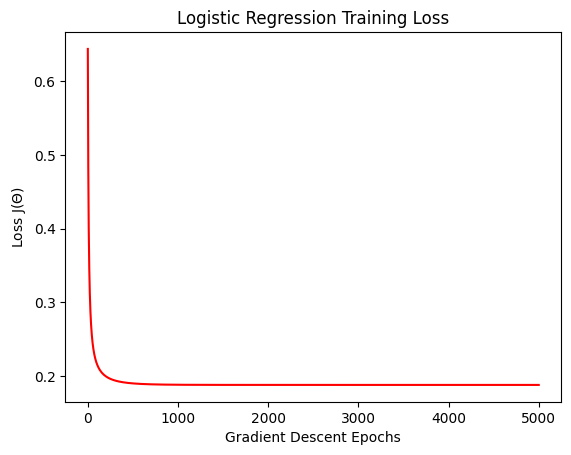

In [58]:
# ===============================================
# MODULE 3: MODLE TRAINING & LOSS VISULISATION
# ===============================================



# The Design matrix 
X_train_b = np.c_[np.ones(len(X_train)), X_train]
X_test_b = np.c_[np.ones(len(X_test)), X_test]

# Intitizling the coefficent 
theta_init = np.zeros(X_train_b.shape[1])

# Intitial Parameter
learning_rate = 0.1
epochs = 5000

theta_final, loss = logistic_gradient_descent(X_train_b, y_train, theta_init, learning_rate, epochs)

print(f"Minimum loss :{np.min(loss):.4f}")

plt.plot(loss, color='red')
plt.xlabel('Gradient Descent Epochs')
plt.ylabel(r'Loss J($\Theta$)')
plt.title('Logistic Regression Training Loss')
plt.show()


In [59]:
# ==========================================
# MODULE 4: MODLE EVALUATION (Custom Model) 
# ==========================================


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred = predict_pro(X_test_b, theta_final)

print("--- Model Score Board ---")
print(f"Accuracy of the Model : {100 * accuracy_score(y_test, y_pred):.2f}%")
print(f"Precision of the model : {precision_score(y_test, y_pred):.4f}")
print(f"Recall : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score :{f1_score(y_test, y_pred):.4f}")

--- Model Score Board ---
Accuracy of the Model : 93.00%
Precision of the model : 0.9100
Recall : 0.9479
F1 Score :0.9286


In [60]:
# ==========================================
# MODULE 5: MODLE EVALUATION (Sci-kit learn) 
# ==========================================

from sklearn.linear_model import LogisticRegression

logis_regression = LogisticRegression()
logis_regression.fit(X_train, y_train)
y_pred_sk= logis_regression.predict(X_test)

print("--- Sklearn Score Board ---")
print(f"Sklearn Accuracy : {100 *accuracy_score(y_test, y_pred_sk)}%")
print(f"Precision of the model : {precision_score(y_test, y_pred_sk):.4f}")
print(f"Recall : {recall_score(y_test, y_pred_sk):.4f}")
print(f"F1 Score :{f1_score(y_test, y_pred_sk):.4f}")


--- Sklearn Score Board ---
Sklearn Accuracy : 93.0%
Precision of the model : 0.9100
Recall : 0.9479
F1 Score :0.9286


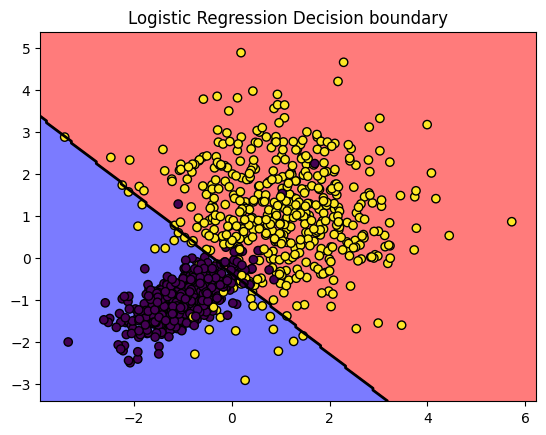

In [61]:
# =======================================================
#  MODULE 6: VISULISATION OF DISICION BOUNDARY ON CONTOR
# =======================================================


#creating the mesh  
x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
y_min, y_max = X[:,1].min() -0.5, X[:,1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[np.ones(xx.ravel().shape[0]), xx.ravel(), yy.ravel()]
z = predict_pro(grid, theta_final).reshape(xx.shape)

plt.contourf(xx, yy, z, alpha = 0.6, cmap='bwr')
plt.contour(xx, yy, z, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
plt.title('Logistic Regression Decision boundary')
plt.show() 

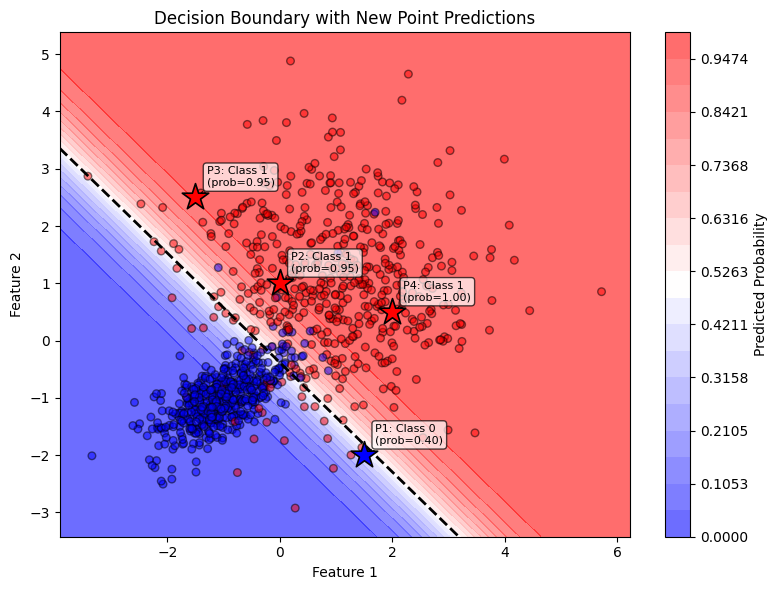

Point     Feature 1  Feature 2  Probability   Prediction
-------------------------------------------------------
P1             1.50      -2.00       0.4040      Class 0
P2             0.00       1.00       0.9459      Class 1
P3            -1.50       2.50       0.9526      Class 1
P4             2.00       0.50       0.9969      Class 1


In [62]:
# ==================================================
#  MODULE 7: VISULISATION OF NEW POINTS ON CONTOR
# ==================================================
 

# Defining custom points [Feature 1, Feature 2]
new_points = np.array([
    [ 1.5, -2.0],
    [ 0.0,  1.0],
    [-1.5,  2.5],
    [ 2.0,  0.5],
])

# Add bias column (same as X_train_b)
new_points_b = np.c_[np.ones(len(new_points)), new_points]

# Get predicted class and probability
new_probs  = sigmoid(new_points_b @ theta_final)
new_preds  = (new_probs >= 0.5).astype(int)

# ── Recreate the contour (probability gradient) ───
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid  = np.c_[np.ones(xx.ravel().shape[0]), xx.ravel(), yy.ravel()]
prob  = sigmoid(grid @ theta_final).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))

# Probability heatmap background
cf = ax.contourf(xx, yy, prob, levels=np.linspace(0, 1, 20), cmap='bwr', alpha=0.6)
plt.colorbar(cf, ax=ax, label='Predicted Probability')

# Decision boundary line
ax.contour(xx, yy, prob, levels=[0.5], colors='black', linewidths=2, linestyles='--')

# Training data
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', alpha=0.5, s=30)

# ── Plot new points as stars ───
for i, (pt, pred, prob_val) in enumerate(zip(new_points, new_preds, new_probs)):
    color = 'red' if pred == 1 else 'blue'
    ax.scatter(pt[0], pt[1], c=color, marker='*', s=400,
               edgecolors='black', linewidths=1.2, zorder=5)
    ax.annotate(f"P{i+1}: {'Class 1' if pred==1 else 'Class 0'}\n(prob={prob_val:.2f})",
                xy=(pt[0], pt[1]),
                xytext=(pt[0] + 0.2, pt[1] + 0.2),
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7),
                arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Decision Boundary with New Point Predictions')
plt.tight_layout()
plt.show()

# ── Summary table ──
print(f"{'Point':<8} {'Feature 1':>10} {'Feature 2':>10} {'Probability':>12} {'Prediction':>12}")
print("-" * 55)


for i, (pt, pred, pv) in enumerate(zip(new_points, new_preds, new_probs)):
    print(f"P{i+1:<7} {pt[0]:>10.2f} {pt[1]:>10.2f} {pv:>12.4f} {'Class 1' if pred==1 else 'Class 0':>12}")

# Confusion Matrix Heatmap Analysis

### 1. Conceptual Framework of a Confusion Matrix
A **Confusion Matrix** is a structural 2x2 performance tracking grid used to evaluate the operational accuracy of a binary classification model. Unlike global evaluation scores (like standard accuracy), a confusion matrix isolates exactly where a model is making correct predictions versus where it is tripping over specific classification errors.

The code implements a side-by-side comparative heatmap overlaying two distinct algorithmic pipelines:
1. **The Custom Model**: Driven by our hand-coded vectorized matrix gradient descent loop (\(\theta := \theta - \alpha \frac{1}{m} X^T(H-Y)\)).
2. **The Sklearn Model**: Driven by scikit-learn's underlying coordinate descent solver engine.

---

### 2. Anatomical Mapping of the Heatmap Grid
The script maps rows to the **Actual Ground-Truth Labels (Y)** and columns to the **Predicted Decision Boundary Outputs (Ŷ)**. Every data point falls into one of four quadrants:

```text
                       PREDICTED (Columns)
                     Pred 0          Pred 1
                 ┌───────────────┬───────────────┐
          True 0 │ True Negative │ False Positive│
                 │     (TN)      │     (FP)      │
  ACTUAL         ├───────────────┼───────────────┤
  (Rows)  True 1 │ False Negative│ True Positive │
                 │     (FN)      │     (TP)      │
                 └───────────────┴───────────────┘
```

#### I. True Negatives (TN) $\to$ [Top-Left Quadrant]
* **What it tells **: The model correctly classified healthy/negative cases as `0`. 
* **Model Meaning**: Represents solid baseline stability. High TN counts mean the model is not over-reacting or inventing artificial anomalies in standard environments.

#### II. False Positives (FP) $\to$ [Top-Right Quadrant]
* **What it tells **: **False Alarms**. The true label was `0`, but the model incorrectly flagged it as `1`.
* **Model Meaning**: High FP values indicate that your parameter vector $\theta$ is overly aggressive or your decision threshold $\tau_{\text{thresh}}$ is too low. In fraud detection, this means annoying legitimate clients by freezing standard cards.

#### III. False Negatives (FN) $\to$ [Bottom-Left Quadrant]
* **What it tells **: **Missed Cases**. The true label was `1`, but the model completely missed it and predicted a `0`.
* **Model Meaning**: This is the most dangerous classification error zone. High FN values indicate that your weights are under-reacting to critical indicators. In medical diagnostics, this means sending a sick patient home under the false impression they are healthy.

#### IV. True Positives (TP) $\to$ [Bottom-Right Quadrant]
* **What it tells **: **Successful Hits**. The model correctly caught a true positive instance and labeled it a `1`.
* **Model Meaning**: Measures the direct utility value of the classification engine. High TP counts confirm that the model's spatial decision boundary passes accurately through the feature clusters of the target class.

---

### 3. Engineering Insights Derived from the Heatmap Comparison

#### Evaluating Mathematical Convergence
If your custom vectorized gradient descent code was written correctly, the numeric counts inside the `Custom Model` heatmap should be nearly identical (or completely identical) to the `Sklearn Model` heatmap. 
* **If they match**: It proves your manual matrix calculus derivatives ($\frac{1}{m} X^T(H-Y)$) and optimization update steps converged perfectly to the exact same global minimum error terrain as production-grade software frameworks.
* **If they diverge**: It indicates that your learning rate $\alpha$ was improperly scaled, the iterations loop cut off prematurely before reaching convergence, or an unhandled data leakage bug exists during feature formatting.

#### Isolating Class Imbalance Pitfalls
By visually scanning the balance of color shading between quadrants, engineers can immediately detect if a model is "cheating." If a dataset is heavily skewed, a model might achieve 95% overall accuracy by simply dumping every point into the `TN` bucket, which will instantly show up on this plot as an empty, zeroed-out column under `Pred 1`.

---

### 4. Operational Troubleshooting Matrix
When optimizing the model after analyzing this heatmap, apply the following engineering playbook adjustments:

| Visual Observation | Underlying Root Cause | Architectural Fix |
| :--- | :--- | :--- |
| **High FP (False Alarms)** | Boundary sits too close to Class 0 cluster. | Raise decision threshold (e.g., $0.5 \to 0.7$) or inject L2 regularization to shrink weights. |
| **High FN (Missed Cases)** | Boundary sits too deep inside Class 1 cluster. | Lower decision threshold (e.g., $0.5 \to 0.3$) to capture borderline anomalous data. |
| **Mismatched Plots** | Gradient descent failed to hit absolute minimum. | Increase training epochs loop limit or apply feature standardization/normalization. |


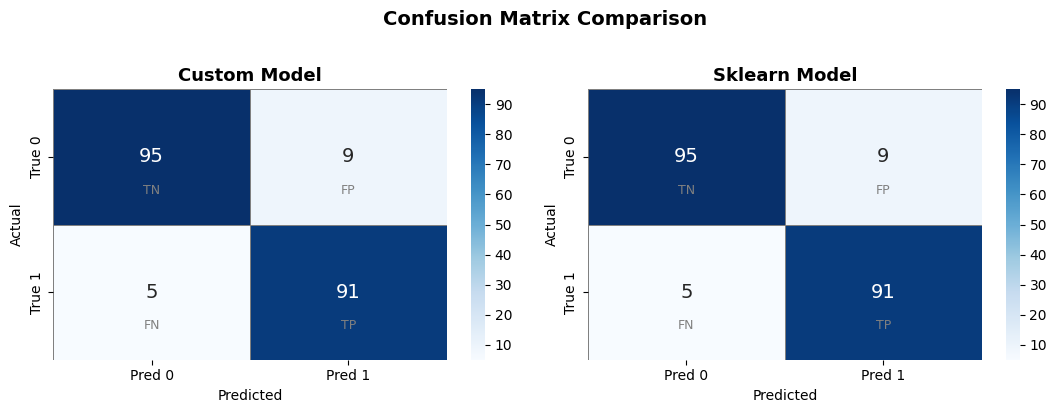

In [ ]:
# ====================================
# MODULE 8.1: CONFUSION MATRIX HEATMAP  
# ====================================

from sklearn.metrics import confusion_matrix

cm_custom = confusion_matrix(y_test, predict_pro(X_test_b, theta_final))
cm_sk     = confusion_matrix(y_test, logis_regression.predict(X_test))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, cm, title in zip(axes,
                          [cm_custom, cm_sk],
                          ['Custom Model', 'Sklearn Model']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'],
                linewidths=0.5, linecolor='gray', annot_kws={"size": 14})
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

    # Label TP / TN / FP / FN
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.75, labels[i][j],
                    ha='center', va='center',
                    fontsize=9, color='gray')

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Threshold Invariant Validation — Receiver Operating Characteristic (ROC) & AUC Analysis

### 1. Conceptual Framework of the ROC Curve
A **Receiver Operating Characteristic (ROC) Curve** is a graphical evaluation plot that maps a binary classifier's performance across **every possible decision threshold** ($\tau_{\text{thresh}}$ ranging from $0.0$ to $1.0$). 

While a Confusion Matrix only evaluates your model at one single arbitrary snapshot threshold (like $\tau = 0.5$), the ROC curve evaluates the underlying separation quality of your probability distributions. It reveals how well your trained coefficient parameters $\theta$ have separated the positive and negative class data point clusters in space, independent of the chosen threshold.

---

### 2. Anatomical Mapping of the Coordinate Space
The ROC plot maps a dynamic trade-off across two specific matrix calculation vectors as the decision boundary threshold slides across your dataset:

$$\text{Y-Axis: True Positive Rate (TPR / Recall)} = \frac{TP}{TP + FN} = \frac{Y^T \hat{Y}}{\mathbf{1}^T Y}$$
* **What it represents**: The percentage of actual positive instances that the model successfully catches. You want this value to hit $1.0$ as fast as possible.

$$\text{X-Axis: False Positive Rate (FPR)} = \frac{FP}{FP + TN} = \frac{(1-Y)^T \hat{Y}}{(1-Y)^T (1-\hat{Y})} = \frac{(1-Y)^T \hat{Y}}{\mathbf{1}^T (1-Y)}$$
* **What it represents**: The percentage of actual negative instances that the model accidentally flags as positive (False Alarms). You want this value to stay pinned down at $0.0$.

#### The Geometric Trajectory (The Baseline Diagonal)
* **The 45-Degree Dashed Diagonal Line ($[0,0]$ to $[1,1]$)**: Represents a completely useless, random-guessing classifier (like flipping a coin). A random model flags false positives and true positives at the exact same rate.
* **The Ideal Profile**: The curve should climb straight up to the top-left corner $(0,1)$, meaning the model achieves $100\%$ True Positive capture with zero False Alarms.

---

### 3. Decoding the Area Under the Curve (AUC)
The **AUC (Area Under the Curve)** converts the visual curve into a single scalar score bounded between $0.5$ and $1.0$. 

* **Probabilistic Interpretation**: If you randomly pick one positive sample and one negative sample from your dataset, the AUC score is the exact probability that your model will assign a higher prediction probability to the positive sample than the negative one.
* **Score Meanings**:
    * $\text{AUC} = 0.5$: No better than a random guess.
    * $0.7 \le \text{AUC} < 0.8$: Acceptable separation.
    * $0.8 \le \text{AUC} < 0.9$: Excellent separation power.
    * $\text{AUC} \ge 0.9$: Outstanding separation capacity.

---

### 4. Engineering Insights Derived from the Comparison

#### Verifying Convergence Efficiency
The code pulls continuous probabilities from your custom matrix setup (`sigmoid(X_test_b @ theta_final)`) and plots them alongside scikit-learn's optimized probability array.
* **If the curves overlap and AUCs match**: This is proof that your custom gradient descent math didn't just find a lucky line for a single threshold—it successfully matched the exact probability mapping space of a industry-standard optimization engine.
* **If your custom AUC is noticeably lower**: This indicates that while your model might look okay on a simple confusion matrix at $\tau=0.5$, your parameters $\theta$ have under-converged. The raw scores ($Z = X\theta$) are clumped together too closely, leaving the model unable to separate the classes across edge-case thresholds.

#### Finding the Optimal Operational Threshold
You can use this graph to pick your final production threshold based on business goals:
* If you need to avoid missing positive cases at all costs, pick a low threshold that maps to a coordinate high up on the curve.
* If you must avoid false alarms, pick a higher threshold that pulls your coordinate down toward the left side of the graph.

---

### 5. Troubleshooting Operational Anomalies

| Observed Curve Trajectory | Underlying Architectural Root Cause | Engineering Adjustment |
| :--- | :--- | :--- |
| **Curve sags below the diagonal line ($\text{AUC} < 0.5$)** | The gradient update rule accidentally added the gradient instead of subtracting it ($+$ instead of $-$). | Flip the sign of your weight update step; your model is predicting the exact inverse of the true classes. |
| **AUC hits exactly $1.0$ on messy real data** | Severe **Data Leakage**. The target column $Y$ (or a feature directly derived from $Y$) was accidentally left inside the training matrix $X$. | Audit your data pipeline. Remove features that leak the true label before the prediction step. |
| **Custom AUC is highly volatile compared to Sklearn** | Unstandardized features caused the gradient descent engine to bounce erratically across the cost landscape. | Apply Min-Max or Z-Score feature scaling to stabilize feature ranges. |


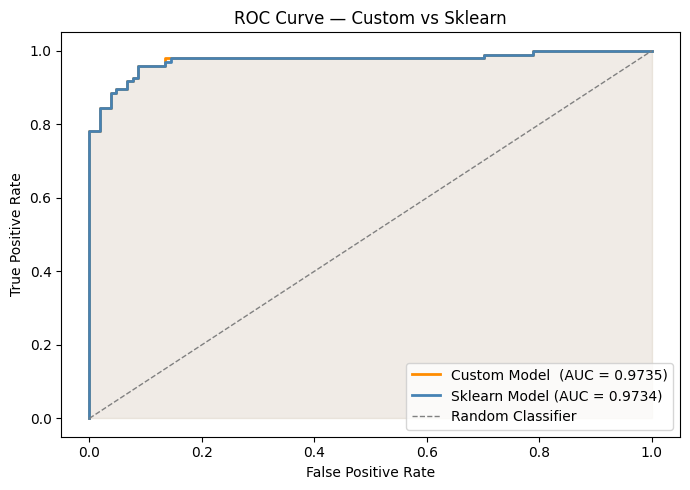

Custom Model AUC  : 0.9735
Sklearn Model AUC : 0.9734


In [64]:
# =======================
# MODULE 8.2: ROC CURVE  
# =======================

from sklearn.metrics import roc_curve, auc

# Custom model probabilities
custom_probs = sigmoid(X_test_b @ theta_final)

# Sklearn probabilities
sklearn_probs = logis_regression.predict_proba(X_test)[:, 1]

# Compute ROC
fpr_custom, tpr_custom, _ = roc_curve(y_test, custom_probs)
fpr_sk,     tpr_sk,     _ = roc_curve(y_test, sklearn_probs)

auc_custom = auc(fpr_custom, tpr_custom)
auc_sk     = auc(fpr_sk,     tpr_sk)

plt.figure(figsize=(7, 5))
plt.plot(fpr_custom, tpr_custom, color='darkorange', lw=2,
         label=f'Custom Model  (AUC = {auc_custom:.4f})')
plt.plot(fpr_sk,     tpr_sk,     color='steelblue',  lw=2,
         label=f'Sklearn Model (AUC = {auc_sk:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.fill_between(fpr_custom, tpr_custom, alpha=0.08, color='darkorange')
plt.fill_between(fpr_sk,     tpr_sk,     alpha=0.08, color='steelblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Custom vs Sklearn')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Custom Model AUC  : {auc_custom:.4f}")
print(f"Sklearn Model AUC : {auc_sk:.4f}")

#  The Probabilistic Bridge — Sigmoid Curve & Sample Projections

### 1. Conceptual Framework of the Sigmoid Projection
While the **Decision Boundary** shows how the model separates data in the feature space ($X_1, X_2$), the **Sigmoid Curve** plot visualizes the model's internal confidence. It transforms the multi-dimensional linear score ($z = X\theta$) into a single probability dimension ($P \in [0, 1]$).

This module bridges the gap between the raw mathematical output of our matrix multiplication and the final binary classification decision.

---

### 2. Anatomical Mapping of the Coordinate Space

#### I. The Input Axis: Linear Score ($z$)
The X-axis represents $z = \theta_0 + \theta_1 x_1 + \dots + \theta_n x_n$. 
* **Terminology**: In machine learning, this value is often called the **Logit**. 
* **Meaning**: It represents the "distance" of a sample from the decision boundary. 
    * $z = 0$: The sample sits exactly on the decision boundary.
    * $z \gg 0$: The sample is deep in the territory of Class 1.
    * $z \ll 0$: The sample is deep in the territory of Class 0.

#### II. The Output Axis: Predicted Probability ($\sigma(z)$)
The Y-axis represents the hypothesis $H = \frac{1}{1 + e^{-z}}$.
* **Threshold Line ($0.5$):** This horizontal boundary separates the classes. Any sample landing above this line is classified as `1`; anything below is classified as `0`.

---

### 3. Engineering Insights Derived from the Visualization

#### I. Analyzing Sample "Certainty"
The scatter points (Test samples) projected onto the curve reveal how confident the model is:
* **Points at the Extremes (Plateaus):** Samples with very high positive or negative $z$ values sit on the flat parts of the sigmoid curve. These are "easy" cases where the model is nearly $100\%$ certain of the class.
* **Points in the "S-Curve" Slope:** Samples near $z=0$ sit on the steep part of the curve. These are "borderline" cases. If many points are clustered here, it indicates that the two classes are overlapping or that the features provided are not strong enough to create a clear separation.

#### II. Class Separation Quality
* **Steelblue Clusters (Class 0):** Ideally, these should all be clustered on the bottom-left tail.
* **Tomato Clusters (Class 1):** Ideally, these should all be clustered on the top-right tail.
* **Overlaps:** If you see "Tomato" points at the bottom or "Steelblue" points at the top, those represent the **False Negatives** and **False Positives** we identified in the Confusion Matrix.

---

### 4. Mathematical Interpretation of Parameters

The shape of this curve is a direct result of our optimized coefficient vector $\theta$:
* **Weight Magnitude**: If the values in $\theta$ are very large, the S-curve becomes very steep (almost like a step function), indicating a very "aggressive" model.
* **Bias Impact ($\theta_0$):** The intercept shifts the entire set of points left or right along the Z-axis, determining where the "tipping point" ($0.5$ probability) occurs relative to the raw feature values.

---

### 5. Summary Table for Technical Documentation

| Term | Mathematical Definition | Role in this Visualization |
| :--- | :--- | :--- |
| **Logit ($z$)** | $X\theta$ | The horizontal position; determines how far a point is from "doubt." |
| **Sigmoid ($\sigma$)** | $1 / (1 + e^{-z})$ | The vertical position; squashes the score into a probability $[0, 1]$. |
| **Threshold** | $\hat{y} = \mathbb{I}(H \ge 0.5)$ | The horizontal gray line; the "Decision Point" for hard labels. |
| **Saturation** | $z \to \pm \infty$ | When the curve flattens; indicates high model confidence. |


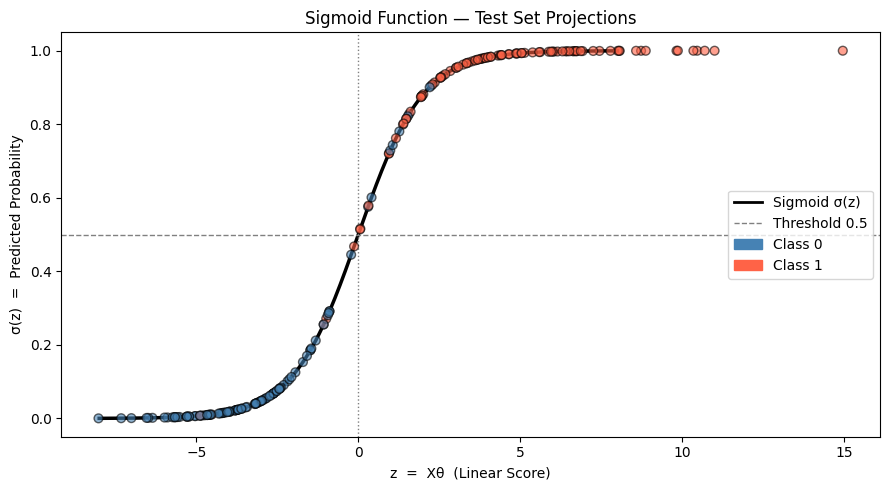

In [65]:
# ===========================
# MODULE 8.3: SIGMOID CURVE  
# ===========================

z_vals   = X_test_b @ theta_final          # linear scores for test set
prob_vals = sigmoid(z_vals)                 # their probabilities

z_line = np.linspace(-8, 8, 300)
sig_line = sigmoid(z_line)

plt.figure(figsize=(9, 5))
plt.plot(z_line, sig_line, color='black', lw=2.5, label='Sigmoid σ(z)')
plt.axhline(0.5, color='gray', linestyle='--', lw=1, label='Threshold = 0.5')
plt.axvline(0.0, color='gray', linestyle=':',  lw=1)

# Scatter actual data points projected onto the curve
colors = ['steelblue' if yi == 0 else 'tomato' for yi in y_test]
plt.scatter(z_vals, prob_vals, c=colors, edgecolors='k',
            alpha=0.6, s=40, zorder=5, label='Test samples')

# Custom legend patches
import matplotlib.patches as mpatches
patch0 = mpatches.Patch(color='steelblue', label='Class 0')
patch1 = mpatches.Patch(color='tomato',    label='Class 1')
plt.legend(handles=[plt.Line2D([0],[0], color='black', lw=2, label='Sigmoid σ(z)'),
                    plt.Line2D([0],[0], color='gray',  lw=1, linestyle='--', label='Threshold 0.5'),
                    patch0, patch1], loc='center right')

plt.xlabel('z  =  Xθ  (Linear Score)')
plt.ylabel('σ(z)  =  Predicted Probability')
plt.title('Sigmoid Function — Test Set Projections')
plt.tight_layout()
plt.show()

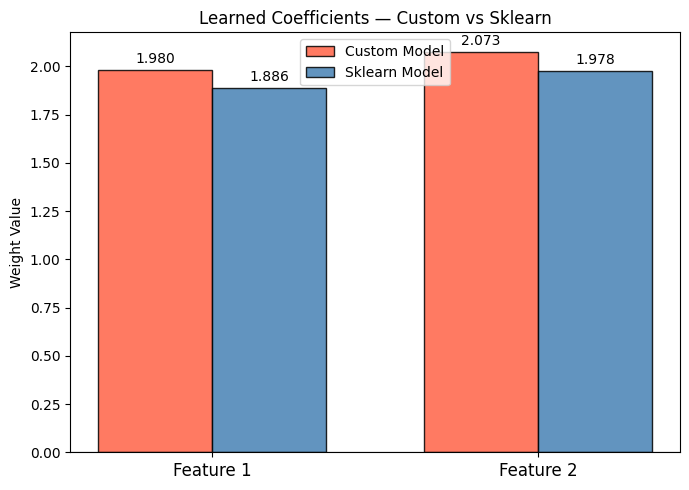


Custom  →  bias: 0.7875 | w1: 1.9796 | w2: 2.0729
Sklearn →  bias: 0.7280 | w1: 1.8862 | w2: 1.9781


In [66]:
# ==================================
# MODULE 8.4: COEFFICIENT BAR CHART  
# ==================================

feature_names  = ['Feature 1', 'Feature 2']
custom_weights = theta_final[1:]           # drop bias term
sk_weights     = logis_regression.coef_[0]

x      = np.arange(len(feature_names))
width  = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, custom_weights, width, label='Custom Model',
               color='tomato',    edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, sk_weights,     width, label='Sklearn Model',
               color='steelblue', edgecolor='black', alpha=0.85)

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02 * np.sign(bar.get_height()),
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02 * np.sign(bar.get_height()),
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(feature_names, fontsize=12)
ax.set_ylabel('Weight Value')
ax.set_title('Learned Coefficients — Custom vs Sklearn')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nCustom  →  bias: {theta_final[0]:.4f} | w1: {theta_final[1]:.4f} | w2: {theta_final[2]:.4f}")
print(f"Sklearn →  bias: {logis_regression.intercept_[0]:.4f} | w1: {sk_weights[0]:.4f} | w2: {sk_weights[1]:.4f}")